In [1]:
from Fluence_fit import *
from h5glance import H5Glance
import h5py
import os
import numpy as np
import matplotlib.pyplot as pl
import sys
import NuRadioReco.utilities.fft as fft_u
conversion_fieldstrength_cgs_to_SI = 2.99792458e10*1e-6


In [2]:
SIM = h5py.File("/user/vitaldehenau/Github/pyMGMR3D/run/outputs/SIM000001.hdf5")
H5Glance(SIM)

print(SIM["observers/pos_010_045"][:, -1])
print(SIM["observers/pos_010_045"][:, -2])
print(SIM["observers/pos_010_045"][:, -3])
print(" ")

print(SIM["observers/pos_010_045"][:, 5:8].T)
print(SIM["observers/pos_010_045"][:, 5:8].shape)



[0. 0. 0. ... 0. 0. 0.]
[5123.09955008 5150.99136089 5128.65557432 ... 5139.87120461 5117.54706866
 5145.42952532]
[184029.48812622 187126.54034102 184228.91331167 ... 186628.68053973
 183731.11222654 186828.50986935]
 
[[184029.48812622 187126.54034102 184228.91331167 ... 186628.68053973
  183731.11222654 186828.50986935]
 [  5123.09955008   5150.99136089   5128.65557432 ...   5139.87120461
    5117.54706866   5145.42952532]
 [     0.              0.              0.         ...      0.
       0.              0.        ]]
(5468, 3)


In [3]:
print(list(SIM["/inputs"].attrs))

print(" ")
print(list(SIM["/observers/pos_010_045"].attrs))
print((SIM["/observers/pos_010_045"].attrs["columns"]))
print((SIM["/observers/pos_010_045"].attrs["units"]))

print(" ")
print(list(SIM["/atmosphere/Currents"].attrs))
print(list(SIM["/atmosphere/Currents"].attrs["columns"]))
print(list(SIM["/atmosphere/Force"].attrs["columns"]))
print(list(SIM["/atmosphere/Geometry"].attrs["columns"]))


['AlternativeSmooth', 'Azi_sh', 'D_ESmooth', 'ENERGY_SH2', 'F_lim', 'Fit_StI', 'GROUNDLEVEL', 'IntegrateCurrent', 'Intensity_Weight', 'Intensity_weight', 'J0Q', 'J0T', 'MOLIERERADIUS', 'ObsDist_dim', 'OutFileLabel', 'RnrmA', 'RnrmB', 'SAMPLINGTIME', 'StParRange', 'X_02', 'X_MAX2', 'X_max', 'Zen_sh', 'azi_B', 'energy_sh', 'lamx', 'lamx2', 'nu_max', 'nu_min', 'u0', 'x_0', 'zen_B']
 
['columns', 'position', 'units']
[b't_us' b'Re_Ex' b'Im_Ex' b'Re_Ey' b'Im_Ey' b'Ex' b'Ey' b'Ez']
[b'us' b'V/m' b'V/m' b'V/m' b'V/m' b'V/m' b'V/m' b'V/m']
 
['columns']
[b'Ix', b'Iy', b'charge_excess', b'dxi']
[b'Fx', b'Fy', b'F_mag_keVpm', b'phi']
[b'z_km', b'X_gcm2', b'refractivity', b'alpha_tr']


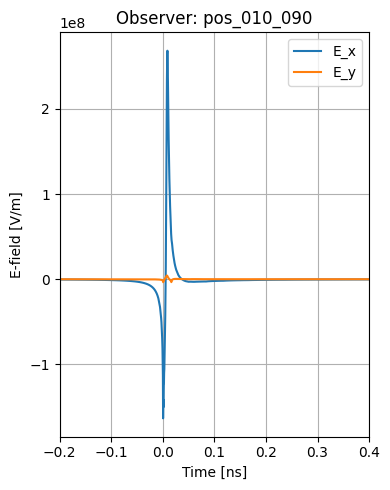

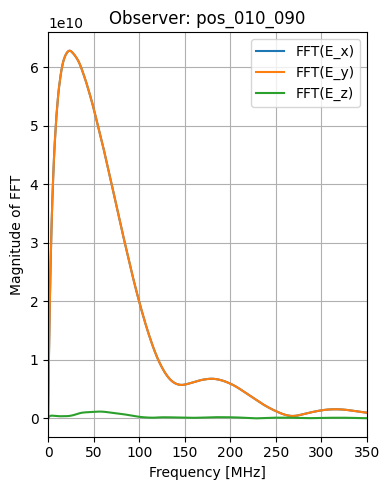

In [9]:
def plot_traces_of_antennas(sim, positions):

    num_positions = len(positions)
    cols = min(5, num_positions)
    rows = (num_positions + cols - 1) // cols

    fig, axes = pl.subplots(rows, cols, figsize=(4 * cols, 5 * rows), sharey=True)

    if rows > 1:
        axes = axes.flatten()
    else:
        axes = np.array(axes).flatten()

    for i, pos in enumerate(positions):
        t = sim[f"/observers/{pos}"][:, 0]
        E = sim[f"/observers/{pos}"][:, 1:8].T
        #E = filter_trace(E, 50, 350, sim["inputs"].attrs["SAMPLINGTIME"]) #MHz filter
        ax = axes[i]
        ax.grid()
        ax.plot(t, E[1], label="E_x")
        ax.plot(t, E[3], label="E_y")
        #ax.plot(t, E[-1], label="E_z")
        ax.set_xlabel("Time [ns]")
        ax.set_xlim((-0.2, 0.4))
        if i % cols == 0:
            ax.set_ylabel("E-field [V/m]") #μV/m
        ax.set_title(f"Observer: {pos}")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    pl.show()
    
def plot_fft_traces_of_antennas(sim, positions):

    num_positions = len(positions)
    cols = min(5, num_positions)
    rows = (num_positions + cols - 1) // cols 

    fig, axes = pl.subplots(rows, cols, figsize=(4 * cols, 5 * rows), sharey=True)

    if rows > 1:
        axes = axes.flatten()
    else:
        axes = np.array(axes).flatten()

    for i, pos in enumerate(positions):
        t = sim[f"/observers/{pos}"][:, 0]
        E = sim[f"/observers/{pos}"][:, 1:4].T
        sampling_period = sim["inputs"].attrs["SAMPLINGTIME"]

        freq = np.fft.rfftfreq(t.size, d=sampling_period)
        fft_E_x, fft_E_y, fft_E_z = fft_u.time2freq(E, sampling_period)

        ax = axes[i]
        ax.grid()
        ax.plot(freq*1000, np.abs(fft_E_x), label="FFT(E_x)")
        ax.plot(freq*1000, np.abs(fft_E_y), label="FFT(E_y)")
        ax.plot(freq*1000, np.abs(fft_E_z), label="FFT(E_z)")

        ax.set_xlim((0, 350))
        ax.set_xlabel("Frequency [MHz]")
        ax.set_ylabel("Magnitude of FFT")
        ax.set_title(f"Observer: {pos}")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    pl.show()

plot_traces_of_antennas(SIM,["pos_010_090"])
plot_fft_traces_of_antennas(SIM,["pos_010_090"])


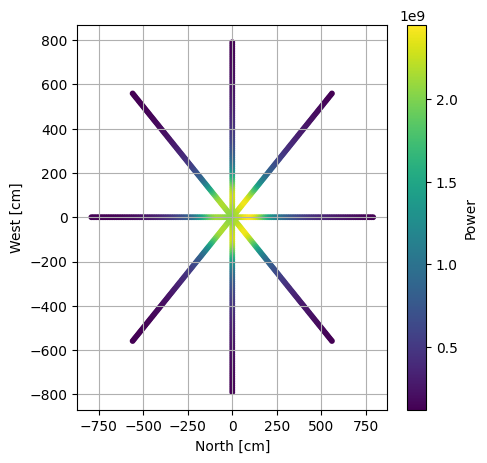

In [118]:
def plot_antenna_positions(sim):
    
    fig = pl.figure(figsize=(5,5))
    pl.grid()

    x, y, P_total = np.array([]), np.array([]), np.array([])

    for pos in sim["/observers"]:
        position = sim[f"/observers/{pos}"].attrs["position"]
        E = np.array((sim[f"/observers/{pos}"][:, 1:5]).T) #GV/m
        #E = filter_trace(E, 300, 350, sim["inputs"].attrs["SAMPLINGTIME"]) #ns
        x, y, P_total  = np.append(x, position[0]), np.append(y, position[1]), np.append(P_total, np.sqrt(np.sum(E**2)))

    sc = pl.scatter(x, y, c=P_total, s=10, cmap="viridis")
    pl.colorbar(sc, label="Power")
    pl.xlabel("North [cm]")
    pl.ylabel("West [cm]")
    pl.show()

plot_antenna_positions(SIM)

In [119]:
def observer_to_si_geomagnetic(observer):

    data = np.copy(observer)
    data[:, 5], data[:, 6] = -observer[:, 6], observer[:, 5]
    data[:, 5:] *= conversion_fieldstrength_cgs_to_SI
    
    return data


def filter_trace(trace, low_freq, high_freq, sampling_period, axis=1):

    freq = np.fft.rfftfreq(trace.shape[axis], d=sampling_period)
    freq_mask = np.logical_or(freq <= low_freq * 1e6, freq >= high_freq * 1e6)
    print(freq_mask)
    
    fft = np.fft.rfft(trace, axis=axis)
    fft[:, freq_mask] *= 0.0  # does not work nicely with axis argument

    print(np.fft.irfft(fft, axis=axis))

    return np.fft.irfft(fft, axis=axis)

def get_pos_and_signals(sim):

    # Read in the simulation file
    reader = h5py.File(sim)
    
    sampling_period = reader["inputs"].attrs["SAMPLINGTIME"]

    # Make coordinate transformation object
    zenith = np.deg2rad(reader['inputs'].attrs["Zen_sh"])
    azimuth = hp.get_normalized_angle(3 * np.pi / 2. + np.deg2rad(reader['inputs'].attrs["Azi_sh"]))
    By, minBz = 18.6, 45.6
    transformer = cs.cstrafo(zenith, azimuth, magnetic_field_vector=np.array([0, By, -1 * minBz]))

    # Transform the antenna positions to shower plane
    pos_ground = []
    signals_on_sky = []
    signals_start_time = []
    for observer in reader['observers'].values():
        
        obs_pos_ground = observer.attrs['position']
        pos_ground.append([-1 * obs_pos_ground[1], obs_pos_ground[0], 760])
        signal = observer_to_si_geomagnetic(observer)
        signals_start_time.append(signal[0, 0])
        signal_ground = transformer.transform_from_magnetic_to_geographic(signal[:,5:].T)
        signal_on_sky = transformer.transform_from_ground_to_onsky(signal_ground)

        signals_on_sky.append(signal_on_sky.T)

    pos_ground = np.asarray(pos_ground)
    signals_on_sky = np.asarray(signals_on_sky)

    pos_showerplane = transformer.transform_to_vxB_vxvxB(pos_ground, core=np.array([0, 0, 760]))
    pos_showerplane /= 100  # convert to m

    reader.close()
    r = np.sqrt(pos_showerplane[:, 0]**2 + pos_showerplane[:, 1]**2)

    return pos_showerplane, signals_on_sky, signals_start_time, sampling_period


def get_fluence_interpolator(sim, low, high):

    pos_showerplane, signals, signals_start_time, signals_sampling_period = get_pos_and_signals(sim)
    fluence_in_band = np.sum(filter_trace(signals, low, high, signals_sampling_period) ** 2, axis=(1, 2)) #(V/m)**2
    fluence_in_band *= speed_of_light_times_epsilon_0_SI*signals_sampling_period # (V/m)**2 * J/s 1/V**2 * s =  J/m**2
    fluence_in_band *= conversion_factor_Joule_to_eV #J/m**2 -> eV/m**2

    # Make the interpolator
    fluence_interpolator = interp_fourier.interp2d_fourier(
        pos_showerplane[:, 0],
        pos_showerplane[:, 1],
        fluence_in_band,
        fill_value="extrapolate",
        recover_concentric_rings=True
    )
    return fluence_in_band, fluence_interpolator


[ True  True  True ...  True  True  True]
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


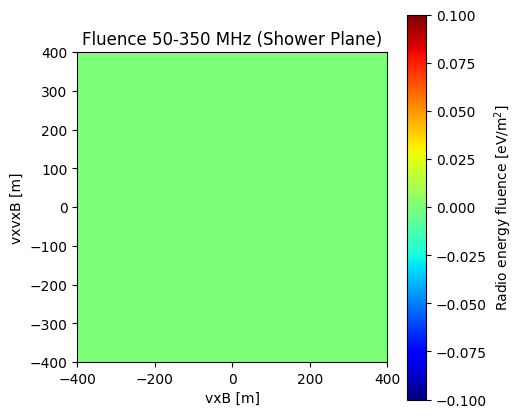

In [120]:
def fluence_plot(sim, low, high, dist_scale):

    ti = np.linspace(-dist_scale, dist_scale, 1000)
    XI, YI = np.meshgrid(ti, ti)
    
    _, fluence_interp = get_fluence_interpolator(sim, low, high)
    ZI = fluence_interp(XI, YI)
    
    fig, ax = pl.subplots(figsize=(5, 5))
    
    im = ax.pcolor(XI, YI, ZI, vmin=0, cmap=cm.jet)
    
    ax.set_title(f'Fluence {low}-{high} MHz (Shower Plane)')
    ax.set_xlabel('vxB [m]')
    ax.set_ylabel('vxvxB [m]')
    ax.set_xlim(-dist_scale, dist_scale)
    ax.set_ylim(-dist_scale, dist_scale)
    ax.set_aspect('equal')
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Radio energy fluence [eV/m$^2$]')
    
    pl.show()

low, high = 50, 350
dist_scale = 400.0
sim = "/user/vitaldehenau/Github/pyMGMR3D/run/outputs/SIM000001.hdf5"

fluence_plot(sim, low, high, dist_scale)

In [121]:
def write_sim_input(run_number, zen_sh, azi_sh,
                    lamx, x_0, X_max, energy_sh,
                    lamx2, X_02, X_MAX2, ENERGY_SH2,
                    output_path):
    """
    Writes a SIMXXXXX.in input file for the simulation.

    Parameters
    ----------
    run_number : int
        Run number for naming the file and OutFileLabel.
    zen_sh, azi_sh : float
        Shower zenith and azimuth angles (degrees).
    lamx, x_0, X_max, energy_sh : float
        Air shower profile parameters for first shower.
    lamx2, X_02, X_MAX2, ENERGY_SH2 : float
        Air shower profile parameters for second shower.
    output_path : str
        Path to write the .in file.
    """
    template = f"""! =?
  &ShPars IntegrateCurrent=-0.01 
  Intensity_Weight=.false.
 SAMPLINGTIME= 5     ! in [ns]
 MOLIERERADIUS=  50.0  ,
 StParRange = -11    ! in down-sampled sample times for calculation of Stokes parameters
 F_lim=1.
 J0T = 14.77, zen_B=22.19 , azi_B=-90.   ! direction magnetic field at LOFAR (49.5 mu T)
 lamx={lamx}, x_0={x_0}, X_max={X_max}, GROUNDLEVEL=  7.6
 D_ESmooth= 7. , MOLIERERADIUS= 0, u0 = 10.
 D_ESmooth= 0.4 , AlternativeSmooth = .true.
 J0Q=0.21
 ObsDist_dim= 80
 energy_sh={energy_sh}
 Intensity_weight = .false.
 Fit_StI = .false.
 RnrmA=3.25, RnrmB=0.65
 Zen_sh={zen_sh}, Azi_sh={azi_sh}
nu_min=0 , nu_max=10000
 SAMPLINGTIME= 0.2     ! in [ns]
! ------------------
 lamx2={lamx2}
  X_02=  {X_02}     ,
 X_MAX2=  {X_MAX2}     ,
 ENERGY_SH2= {ENERGY_SH2}     ,
 OutFileLabel="SIM{run_number:06d}" ,
 X_max={X_max}
   &end

 0.0, 0.0 ,0 -0.0  ! shift_x [m], shift_y [m], alpha_vB [deg]  !30,10 or 10,20 or -10,30?

 step
     
   -4,  16, 17, 19, 20, 21, -15
 "data/data_275251207_cut.dat"  

grid  10. 
=================================  nohup ./MGMR3D_TC.sh  >MGMR3D_TC.log 2>&1  &  
"""
    with open(output_path, "w") as f:
        f.write(template)
    print(f"Written input file: {output_path}")

def write_multiple_sim_inputs(run_start, run_end,
                              zen_sh, azi_sh,
                              lamx, x_0, X_max, energy_sh,
                              lamx2, X_02, X_MAX2,
                              output_dir="."):
    """
    Creates X MGMR .in files with varying ENERGY_SH2 values, evenly spaced
    between energy_sh/10 and energy_sh.

    Parameters
    ----------
    run_start : int
        Starting run number.
    run_end : int
        Last run number.
    zen_sh, azi_sh : float
        Shower zenith and azimuth (degrees).
    lamx, x_0, X_max, energy_sh : float
        Shower profile parameters for first component.
    lamx2, X_02, X_MAX2 : float
        Shower profile parameters for second component (except ENERGY_SH2).
    output_dir : str
        Directory where .in files are written.
    """
    os.makedirs(output_dir, exist_ok=True)

    ENERGY_SH2_values = np.linspace(energy_sh / 10, energy_sh, run_end-run_start+1)

    for i, ENERGY_SH2 in enumerate(ENERGY_SH2_values):
        run_number = run_start + i
        output_path = os.path.join(output_dir, f"SIM{run_number:06d}.in")

        write_sim_input(
            run_number=run_number,
            zen_sh=zen_sh,
            azi_sh=azi_sh,
            lamx=lamx,
            x_0=x_0,
            X_max=X_max,
            energy_sh=energy_sh,
            lamx2=lamx2,
            X_02=X_02,
            X_MAX2=X_MAX2,
            ENERGY_SH2=ENERGY_SH2,
            output_path=output_path
        )

run_start=1
run_end=10
zen_sh, azi_sh=45.0, 80.0
lamx, x_0, X_max, energy_sh = 82.15, 100.58, 696.05, 4217212.07
lamx2, X_02, X_MAX2 = 100.0, 749.62, 1121.3
output_dir="./outputs"

#write_multiple_sim_inputs(run_start, run_end, zen_sh, azi_sh,
#                            lamx, x_0, X_max, energy_sh,
#                            lamx2, X_02, X_MAX2, output_dir)

#X_max_1, X_max_2 = 650, 1500
#N_max_1, N_max_2 = 465000, 100000

In [ ]:
sys.path.insert(0, '/user/vitaldehenau/MA_simulations/CODE/')
import double_bump_plots as db

reference_hdf5 = "/user/vitaldehenau/MA_simulations/CODE/HDF5/SIM000064.hdf5"
reference_hdf5 = "/user/vitaldehenau/Github/pyMGMR3D/run/outputs/SIM000001.hdf5"

low, high = 50, 350
dist_scale = 400.0
ti = np.linspace(-dist_scale, dist_scale, 1000)
XI, YI = np.meshgrid(ti, ti)

#_, fluence_interp_reference = db.get_fluence_interpolator(reference_hdf5, low, high)
_, fluence_interp_reference = get_fluence_interpolator(reference_hdf5, low, high)
ZI_reference = fluence_interp_reference(XI, YI)
print(np.sum(ZI_reference))

N_max_1, N_max_2 = 465000, 100000

ZI_list = []
ZI_list_2 = []
N_ratio_list = []
            
h5py_paths = "/user/vitaldehenau/Github/pyMGMR3D/run/outputs/"     

for filename in os.listdir(h5py_paths):
    if filename.endswith(".hdf5"): 
        sim = os.path.join(h5py_paths, filename)
    
        _, fluence_interpolator = get_fluence_interpolator(sim, low, high)
    
        ti = np.linspace(-dist_scale, dist_scale, 1000)
        XI, YI = np.meshgrid(ti, ti)
        ZI = fluence_interpolator(XI, YI)
        print(ZI)
        print(np.sum(ZI))
        
        ZI_list.append(np.sum(ZI/ZI_reference))
        ZI_list_2.append(np.sum(ZI)/np.sum(ZI_reference))
        N_ratio_list.append(N_max_2/N_max_1)

ZI_array = np.array(ZI_list)
ZI_array_2 = np.array(ZI_list_2)
N_ratio_array = np.array(N_ratio_list)

fig, ax = pl.subplots(1, 1, figsize=(5, 5))

ax.scatter(ZI_array, N_ratio_array)
ax.scatter(ZI_array_2, N_ratio_array)

ax.set_xlabel('ZI ration')
ax.set_ylabel('N_ratio')

#pl.legend()
pl.show()


[ True  True  True ...  True  True  True]
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]
0.0
[ True  True  True ...  True  True  True]
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
 

/tmp/ipykernel_85214/1249585037.py:37: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_85214/1249585037.py:38: RuntimeWarning:

invalid value encountered in scalar divide



[ True  True  True ...  True  True  True]
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
0.0
[ True  True  True ...  True  True  True]
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0